# SIV Project: Board Game Analysis
**Students:** Federico Berra and Davide Verzotto

## 1. Environment Setup & Tools

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

cv2.setRNGSeed(42)
np.random.seed(42)

try:
    from cv2.xfeatures2d import matchGMS
    HAS_GMS = True
except (ImportError, AttributeError):
    if hasattr(cv2, "matchGMS"):          
        matchGMS = cv2.matchGMS
        HAS_GMS = True
    else:
        HAS_GMS = False
        print("ATTENZIONE: matchGMS non disponibile -> uso il ratio test di Lowe.")


def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10, 8))
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("on")
    plt.show()

print("Setup Complete. Tools are ready!")

Setup Complete. Tools are ready!


## 2. Selezione manuale dei corner

In [17]:
def pick_points(image_path):
    """Apre l'immagine e raccoglie i punti cliccati (chiudi con un tasto qualsiasi)."""
    img = cv2.imread(image_path)
    points = []

    def click_event(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            print("Clicked:", x, y)

    cv2.imshow("image", img)
    cv2.setMouseCallback("image", click_event)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return points

folder_path = "../dataset/Game_2/"
files = sorted(f for f in os.listdir(folder_path)
               if f.lower().endswith((".png", ".jpg", ".jpeg")))
print("Primo frame:", files[0])   

pts = pick_points(os.path.join(folder_path, files[0]))
print("Punti cliccati:", pts)

Primo frame: 001.png
Punti cliccati: []


## 3. Immagini di riferimento rettificate
Il riferimento del tabellone vuoto definisce il **sistema di coordinate comune** in cui vengono portati tutti i frame. 

In [ ]:
def rotate_left(image):
    return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)


def build_reference(image_path, src_pts, dst_size, dst_pts):
    raw = cv2.imread(image_path)
    if raw is None:
        raise FileNotFoundError(image_path)
    M = cv2.getPerspectiveTransform(np.float32(src_pts), np.float32(dst_pts))
    return cv2.warpPerspective(raw, M, dst_size)


# --- Tabellone completo ---
BoardW, BoardH = 1105, 740
fixed_emptyBoard = build_reference(
   "../dataset/Game_2/001.png",
   [(412, 137), (1523, 132), (1522, 868), (411, 868)],   
   (BoardW, BoardH),
   [[0, 0], [BoardW - 1, 0], [BoardW - 1, BoardH - 1], [0, BoardH - 1]],
)


# #board corners
# board_src = np.float32([[91,16], [885, 19], [920, 1260], [50, 1260]])
# BoardW, BoardH = 1105, 740
# board_dst = np.float32([ [0, BoardH-1],[0, 0], [BoardW-1, 0], [BoardW-1, BoardH-1]])
# rawemptyBoard = cv2.imread("../dataset/empty_board/complete.jpg")
# boardmatrix = cv2.getPerspectiveTransform(board_src, board_dst)
# fixed_emptyBoard = cv2.warpPerspective(rawemptyBoard, boardmatrix, (BoardW, BoardH))

# show_image(fixed_emptyBoard, "Fixed Empty Board")


# --- Geometria del tracciato ---
BORDERS = (40, 54, 40, 38)   # top, bottom, left, right

def build_ring_mask(w, h, borders):
    bt, bb, bl, br = borders
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[0:bt, :] = 255
    mask[h - bb:h, :] = 255
    mask[:, 0:bl] = 255
    mask[:, w - br:w] = 255
    return mask

ring_mask = build_ring_mask(BoardW, BoardH, BORDERS)

## 4. Localizzazione via omografia e allineamento esatto
`align_to_reference`: porta il frame di gioco **pixel per pixel** nelle stesse coordinate del riferimento vuoto (stessa dimensione, stesso allineamento). Questo è indispensabile per la differenza della sezione 6: se le immagini non coincidono al pixel, i numeri stampati non si cancellano.

In [ ]:
def findImage(imageToFind, WholeImage, show_matches=False, return_mask=False):
    """Trova 'imageToFind' (riferimento) dentro 'WholeImage' e riproietta
    WholeImage nel sistema di coordinate del riferimento."""
    orb = cv2.ORB_create(nfeatures=5000)
    kp1, des1 = orb.detectAndCompute(imageToFind, None)
    kp2, des2 = orb.detectAndCompute(WholeImage, None)

    if des1 is None or des2 is None:
        return None

    if (HAS_GMS):
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
        matches = matcher.match(des1, des2)
        good = matchGMS(
            imageToFind.shape[:2], WholeImage.shape[:2],
            kp1, kp2, matches,
            withRotation=False, withScale=True, thresholdFactor=6,
        )
    else:
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
        knn = matcher.knnMatch(des1, des2, k=2)
        good = [m for m, n in knn if m.distance < 0.75 * n.distance]

    if len(good) < 3:                     
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 2)   
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 2)

    M, inlier_mask = cv2.estimateAffinePartial2D(dst_pts, src_pts, method=cv2.RANSAC, ransacReprojThreshold=3.0, maxIters=3000, confidence=0.99, refineIters=10,)
    if M is None:
        return None

    if show_matches:
        inliers = [m for m, keep in zip(good, inlier_mask.ravel().astype(bool)) if keep]
        show_image(
            cv2.drawMatches(imageToFind, kp1, WholeImage, kp2, inliers, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS),
            "Inlier Matches",
        )

    H = np.vstack([M, [0.0, 0.0, 1.0]]).astype(np.float32)   
    out_size = (imageToFind.shape[1], imageToFind.shape[0])
    warped = cv2.warpPerspective(WholeImage, H, out_size)
    if not return_mask:
        return warped
    ones = np.full(WholeImage.shape[:2], 255, np.uint8)
    vmask = cv2.warpPerspective(ones, H, out_size,
                                flags=cv2.INTER_NEAREST,
                                borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return warped, vmask


def findPart(referenceSections, completeImage, show_matches=False):
    for ref in referenceSections:
        result = findImage(ref, completeImage, show_matches=show_matches)
        if result is None:
            print("Localizzazione fallita su uno step della cascata.")
            return completeImage
        completeImage = result
    return completeImage


def crop_image(image, pLeft, pRight, pTop, pBottom):
    height, width = image.shape[:2]
    return image[int(height * pTop): height - int(height * pBottom),
                 int(width * pLeft): width - int(width * pRight)]


def refine_with_ecc(aligned, ref, mask=None, gauss=5, valid_in=None):
    if valid_in is None:
        valid_in = np.full(aligned.shape[:2], 255, np.uint8)

    g_ref = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
    g_img = cv2.cvtColor(aligned, cv2.COLOR_BGR2GRAY)
    warp = np.eye(3, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 300, 1e-6)
    try:
        cc, warp = cv2.findTransformECC(g_ref, g_img, warp,
                                        cv2.MOTION_HOMOGRAPHY, criteria, mask, gauss)
    except cv2.error:
        return aligned, valid_in

    h, w = ref.shape[:2]
    aligned_warped = cv2.warpPerspective(aligned, warp, (w, h),
                                         flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    valid_out = cv2.warpPerspective(valid_in, warp, (w, h),
                                    flags=cv2.INTER_NEAREST + cv2.WARP_INVERSE_MAP,
                                    borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return aligned_warped, valid_out


def find_board_corners(frame, debug=False):
    """Trova i 4 angoli del tabellone (quadrilatero scuro più grande)."""
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    # il tavolo è blu/chiaro, il tabellone scuro: maschera per bassa luminosità
    dark = cv2.inRange(hsv, (0, 0, 0), (180, 255, 110))
    dark = cv2.morphologyEx(dark, cv2.MORPH_CLOSE, np.ones((25, 25), np.uint8))
    dark = cv2.morphologyEx(dark, cv2.MORPH_OPEN,  np.ones((15, 15), np.uint8))
    if debug:
        show_image(dark, "Maschera tabellone", cmap='gray')

    contours, _ = cv2.findContours(dark, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    board = max(contours, key=cv2.contourArea)
    if cv2.contourArea(board) < 0.15 * frame.shape[0] * frame.shape[1]:
        return None   

    peri = cv2.arcLength(board, True)
    for eps in (0.02, 0.03, 0.05):
        approx = cv2.approxPolyDP(board, eps * peri, True)
        if len(approx) == 4:
            return approx.reshape(4, 2).astype(np.float32)
    return None


def order_corners(pts):
    """Ordina i 4 punti: alto-sx, alto-dx, basso-dx, basso-sx."""
    s = pts.sum(axis=1); d = np.diff(pts, axis=1).ravel()
    return np.float32([pts[np.argmin(s)], pts[np.argmin(d)],
                       pts[np.argmax(s)], pts[np.argmax(d)]])


def align_to_reference(frame):
    """ORB/similitudine + raffinamento ECC 'guardato': ogni passo ECC viene
    accettato solo se migliora lo score di allineamento."""
    res = findImage(fixed_emptyBoard, frame, return_mask=True)
    if res is None:
        return None, None
    best_out, best_valid = res
    best_s = alignment_score(best_out, fixed_emptyBoard, valid=best_valid)

    for g in (21, 5):
        cand, cand_valid = refine_with_ecc(best_out, fixed_emptyBoard,
                                           mask=ring_mask, gauss=g, valid_in=best_valid)
        s = alignment_score(cand, fixed_emptyBoard, valid=cand_valid)
        if s > best_s:
            best_out, best_valid, best_s = cand, cand_valid, s
        # altrimenti: ECC ha peggiorato -> lo ignoriamo

    if best_s <= 0.10:
        return None, None
    return best_out, cv2.erode(best_valid, np.ones((7, 7), np.uint8))


def alignment_score(out, ref, valid=None):
    """Correlazione col riferimento nella fascia del tracciato, solo sui pixel validi."""
    zone = ring_mask.copy()
    if valid is not None:
        zone = cv2.bitwise_and(zone, valid)
    if cv2.countNonZero(zone) < 500:      
        return -1.0
    g1 = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)[zone > 0].astype(np.float32)
    g2 = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)[zone > 0].astype(np.float32)
    return np.corrcoef(g1, g2)[0, 1]

### Test di allineamento su un frame

Loaded: 041.png


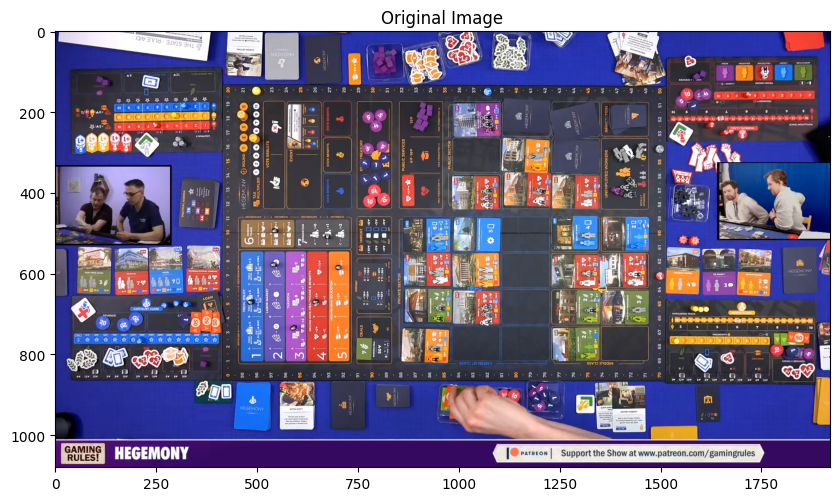

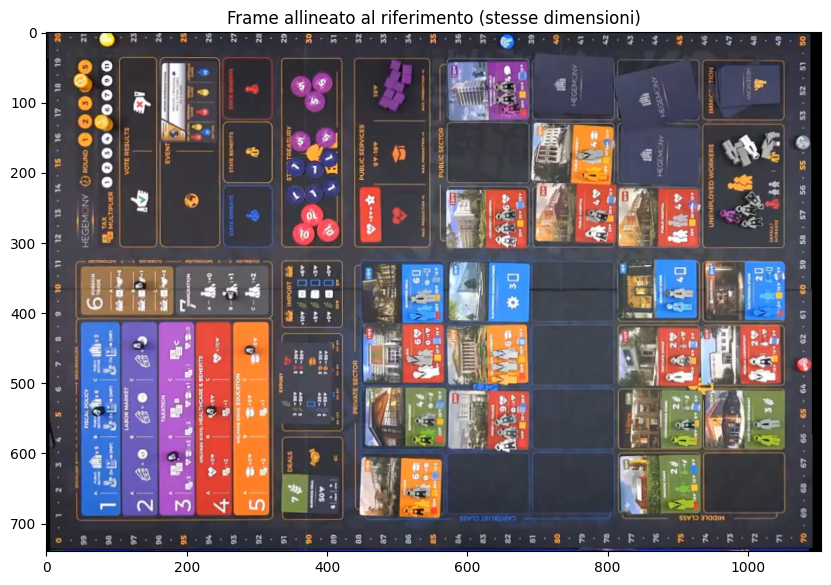

In [65]:
folder_path = "../dataset/Game_2/"
#image_name = sorted(os.listdir(folder_path))[2]
image_name = "041.png"
img = cv2.imread(os.path.join(folder_path, image_name))
print("Loaded:", image_name)

aligned, valid_mask = align_to_reference(img)
if aligned is None:
    raise RuntimeError("Allineamento fallito su questo frame")

masked=cv2.bitwise_and(aligned, aligned, mask=valid_mask)
show_image(img, "Original Image")
show_image(masked, "Frame allineato al riferimento (stesse dimensioni)")

## 5. Modello del tracciato punteggi (costruito una sola volta)
Il tracciato 0–99 corre lungo il perimetro: le caselle sono equispaziate su ogni lato, quindi le loro posizioni si calcolano geometricamente nelle coordinate del riferimento. Sul tabellone Hegemony la disposizione è:

- **bordo inferiore** (da sinistra a destra): 0, 99, 98, …, 70
- **bordo sinistro** (dal basso verso l'alto): 1 … 19
- **bordo superiore** (da sinistra a destra): 20 … 50
- **bordo destro** (dall'alto verso il basso): 51 … 69

**Verifica con l'overlay qui sotto:** ogni numero disegnato deve cadere sulla casella corrispondente del tabellone vuoto. Se qualcosa non coincide, ritoccare `BORDERS` (spessore della fascia) o le liste dei punteggi per lato.

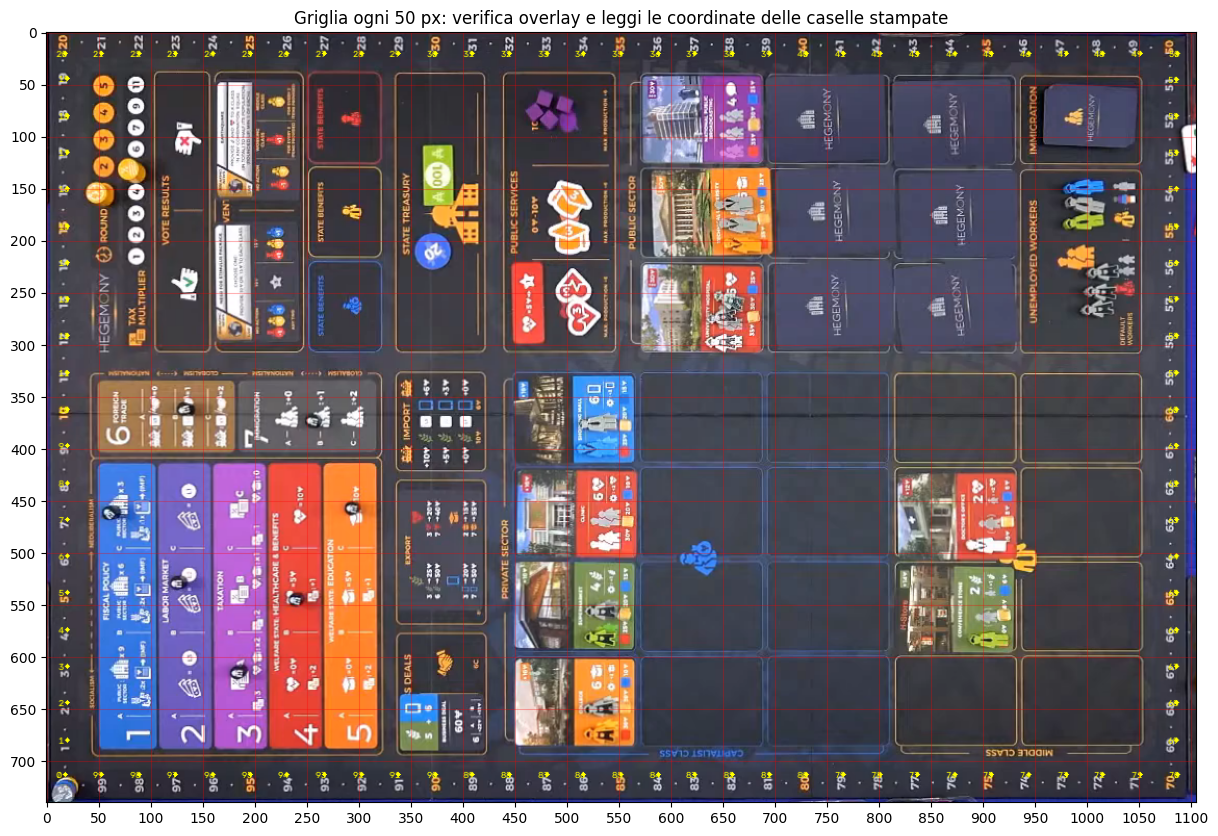

In [66]:
# ============ CONFIGURAZIONE TRACCIATO ============
SCORES_BOTTOM = [0] + list(range(99, 69, -1))   # 31 caselle, da sinistra a destra
SCORES_LEFT   = list(range(1, 20))              # 19 caselle, dal basso verso l'alto
SCORES_TOP    = list(range(20, 51))             # 31 caselle, da sinistra a destra
SCORES_RIGHT  = list(range(51, 70))             # 19 caselle, dall'alto verso il basso

# ---- CALIBRAZIONE: coordinate dei centri delle caselle agli estremi di ogni lato ----
# Leggi questi 8 valori dalla griglia rossa (precisione +/-5 px) e sostituiscili.
x20, x50 = 18, 1087     # bordo ALTO
x0,  x70 = 18, 1087     # bordo BASSO
y1,  y19 = 680, 45      # bordo SINISTRO
y51, y69 = 45, 680      # bordo DESTRO
# -------------------------------------------------------------------------------------


def span_from_centers(c_first, c_last, n):
    """Span tale che la prima e l'ultima casella cadano esattamente su c_first e c_last."""
    d = (c_last - c_first) / (n - 1)
    return (c_first - d / 2, c_last + d / 2)


SPAN_TOP    = span_from_centers(x20, x50, len(SCORES_TOP))
SPAN_BOTTOM = span_from_centers(x0,  x70, len(SCORES_BOTTOM))
SPAN_LEFT   = span_from_centers(y1,  y19, len(SCORES_LEFT))
SPAN_RIGHT  = span_from_centers(y51, y69, len(SCORES_RIGHT))


def _spread(scores, span, fixed_coord, axis):
    a, b = span
    n = len(scores)
    out = {}
    for i, s in enumerate(scores):
        pos = int(a + (i + 0.5) * (b - a) / n)
        out[s] = (pos, fixed_coord) if axis == "x" else (fixed_coord, pos)
    return out


def build_track_model(w, h, borders):
    bt, bb, bl, br = borders
    cells = {}
    cells.update(_spread(SCORES_BOTTOM, SPAN_BOTTOM, h - bb // 2, "x"))
    cells.update(_spread(SCORES_LEFT,   SPAN_LEFT,   bl // 2,      "y"))
    cells.update(_spread(SCORES_TOP,    SPAN_TOP,    bt // 2,      "x"))
    cells.update(_spread(SCORES_RIGHT,  SPAN_RIGHT,  w - br // 2,  "y"))
    return cells


track_cells = build_track_model(BoardW, BoardH, BORDERS)

# --- Overlay di verifica con griglia per la calibrazione ---
overlay = fixed_emptyBoard.copy()
for score, (x, y) in track_cells.items():
    cv2.circle(overlay, (x, y), 2, (0, 255, 255), -1)
    cv2.putText(overlay, str(score), (x - 8, y + 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 1)

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.xticks(range(0, BoardW, 50))
plt.yticks(range(0, BoardH, 50))
plt.grid(True, color='red', alpha=0.3)
plt.title("Griglia ogni 50 px: verifica overlay e leggi le coordinate delle caselle stampate")
plt.show()

## 6. Rilevamento dei dischi segnapunti
Dentro la fascia del tracciato calcoliamo la differenza tra frame allineato e riferimento vuoto: la grafica stampata si cancella, i dischi (e le mani) emergono. I blob vengono filtrati per dimensione e classificati per colore (HSV) per capire a quale classe appartengono.

In [67]:
# ============ PARAMETRI DETECTION ============
DIFF_THRESHOLD  = 60     # soglia sulla differenza (0-255)
MIN_TOKEN_AREA  = 60     # area minima blob (px^2)
MAX_TOKEN_AREA  = 2000   # area massima blob
MAX_TOKEN_SIZE  = 35     # lato massimo del bounding box (anti mano/braccio)
# =============================================

# Riferimento pre-sfocato una sola volta (riduce il rumore della differenza)
_empty_blur = cv2.GaussianBlur(fixed_emptyBoard, (5, 5), 0)


def classify_token_color(hsv):
    """Classifica un colore mediano HSV nella classe di gioco."""
    H, S, V = int(hsv[0]), int(hsv[1]), int(hsv[2])
    if S < 55 and V > 110:
        return "State"
    if S >= 55 and V >= 80:          
        if (H <= 15 or H >= 150) and V>140:
            return "Working"
        if 15 <= H <= 40:
            return "Middle"
        if 90 <= H <= 135:           
            return "Capitalist"
    return None

    


def detect_score_tokens(aligned,maskToValidate, debug=False, ring_mask=None):
    """Trova i dischi segnapunti nella fascia del tracciato.
    Ritorna lista di dict: {class, score, center, area}."""
    frame_blur = cv2.GaussianBlur(aligned, (5, 5), 0)

    # Differenza per canale -> massimo sui canali
    diff = cv2.absdiff(frame_blur, _empty_blur)
    diff = cv2.bitwise_and(diff, diff, mask=maskToValidate)
    diff_gray = diff.max(axis=2).astype(np.uint8)
    diff_gray = cv2.bitwise_and(diff_gray, ring_mask)

    _, binary = cv2.threshold(diff_gray, DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8), iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)
    
    if debug:
        show_image(binary, "Debug: maschera differenza nel tracciato", cmap='gray')

    hsv_img = cv2.cvtColor(aligned, cv2.COLOR_BGR2HSV)
    cnontours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    tokens = []
    for cnt in cnontours:
        area = cv2.contourArea(cnt)
        x, y, bw, bh = cv2.boundingRect(cnt)
        if not (MIN_TOKEN_AREA < area < MAX_TOKEN_AREA):
            if debug:
                print("blob in ", x, "-", y, ", scartato per area:", area)
            continue
        if bw > MAX_TOKEN_SIZE or bh > MAX_TOKEN_SIZE:
            if debug:
                print("blob in ", x, "-", y, ", scartato per dimensione:", bw, bh)
            continue
        ratio = float(bw) / float(bh)
        if 0.4 > ratio or ratio > 1.6:
            if debug:
                print("blob in ", x, "-", y, ", scartato per rapporto:", ratio)
            continue

        M = cv2.moments(cnt)
        if M["m00"] == 0:
            if debug:
                print("blob in ", x, "-", y, ", scartato per momento m00=0")
            continue
        cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])

        # Colore mediano in una patch 7x7 attorno al centroide
        y0, y1 = max(cY - 7, 0), min(cY + 8, aligned.shape[0])
        x0, x1 = max(cX - 7, 0), min(cX + 8, aligned.shape[1])
        patch = hsv_img[y0:y1, x0:x1].reshape(-1, 3)
        hsv_med = np.median(patch, axis=0)

        cls = classify_token_color(hsv_med)

        # Casella piu' vicina
        score = min(track_cells,
                    key=lambda s: (track_cells[s][0] - cX) ** 2 + (track_cells[s][1] - cY) ** 2)

        if debug:
            print(f"blob area={area:5.0f} box={bw}x{bh} HSV={hsv_med.astype(int)} "
                  f"-> classe={cls} casella={score}")

        if cls is not None:
            tokens.append({"class": cls, "score": score, "center": (cX, cY), "area": area})

    return tokens

## 7. Lettura del punteggio su un singolo frame
Ogni classe ha **un solo** disco sul tracciato: se la detection ne trova più di uno (rumore), teniamo quello con area maggiore.

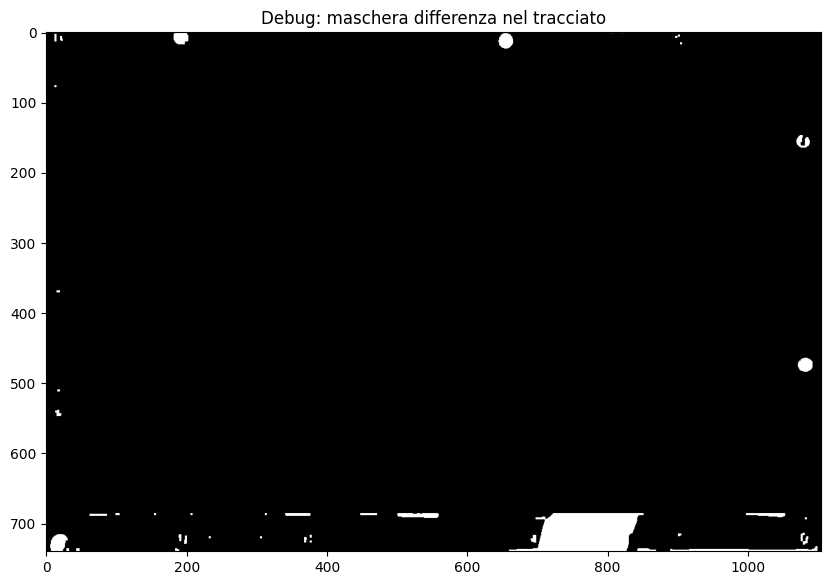

blob in  843 - 736 , scartato per area: 58.5
blob in  184 - 736 , scartato per area: 12.0
blob in  43 - 736 , scartato per area: 12.0
blob in  29 - 736 , scartato per area: 9.0
blob in  890 - 733 , scartato per dimensione: 210 7
blob in  376 - 725 , scartato per area: 4.0
blob in  368 - 720 , scartato per area: 17.0
blob in  305 - 719 , scartato per area: 4.0
blob in  232 - 719 , scartato per area: 4.0
blob in  197 - 718 , scartato per area: 27.0
blob in  691 - 717 , scartato per area: 50.5
blob in  376 - 717 , scartato per area: 6.0
blob in  189 - 716 , scartato per area: 22.0
blob area=  426 box=25x24 HSV=[120  56  49] -> classe=None casella=0
blob in  901 - 715 , scartato per area: 10.5
blob area=   62 box=11x17 HSV=[ 14 102  80] -> classe=None casella=70
blob in  1082 - 692 , scartato per area: 4.0
blob in  62 - 687 , scartato per area: 48.0
blob in  998 - 686 , scartato per dimensione: 56 6
blob in  660 - 686 , scartato per area: 6884.0
blob in  501 - 686 , scartato per dimensione

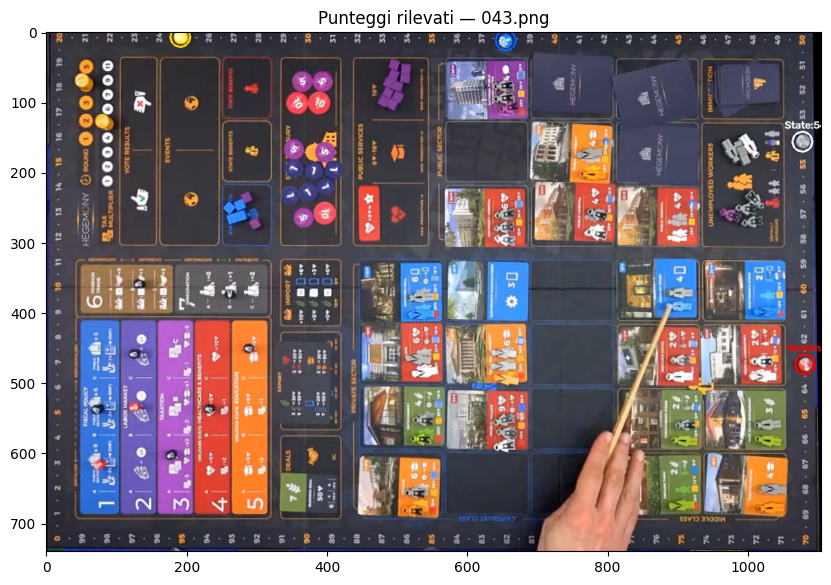

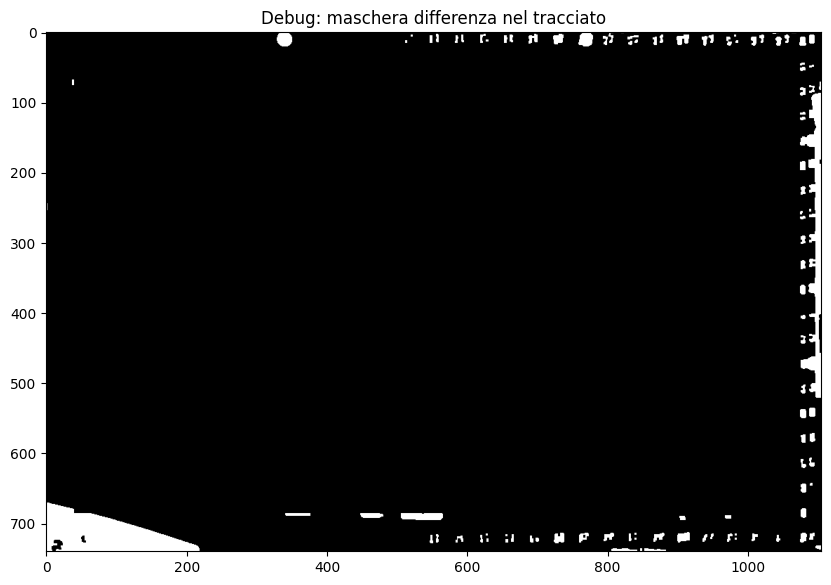

blob in  853 - 736 , scartato per area: 54.0
blob in  847 - 736 , scartato per area: 6.0
blob in  806 - 736 , scartato per dimensione: 37 4
blob in  1097 - 732 , scartato per area: 28.5
blob in  655 - 723 , scartato per area: 12.0
blob in  628 - 722 , scartato per area: 8.0
blob in  982 - 721 , scartato per area: 4.0
blob in  839 - 721 , scartato per area: 4.0
blob in  698 - 721 , scartato per area: 18.5
blob in  690 - 718 , scartato per area: 28.0
blob in  584 - 718 , scartato per area: 36.0
blob in  1041 - 717 , scartato per area: 27.0
blob in  619 - 717 , scartato per area: 21.0
blob in  547 - 717 , scartato per area: 28.5
blob in  936 - 716 , scartato per area: 32.5
blob in  663 - 716 , scartato per area: 24.5
blob in  655 - 716 , scartato per area: 4.0
blob in  556 - 716 , scartato per area: 26.0
blob in  1006 - 715 , scartato per area: 43.0
blob in  982 - 715 , scartato per area: 4.0
blob in  971 - 715 , scartato per area: 36.0
blob in  947 - 715 , scartato per area: 17.0
blob in

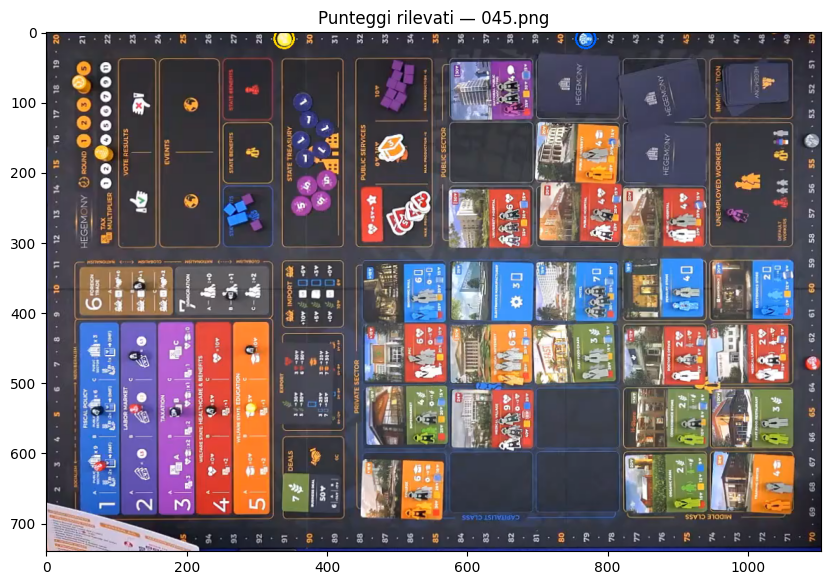

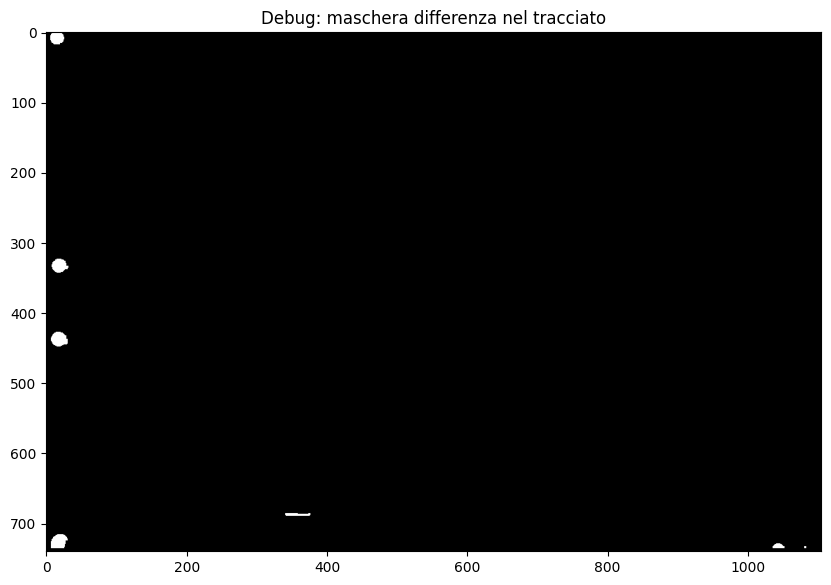

blob in  1081 - 733 , scartato per area: 4.0
blob in  1036 - 729 , scartato per rapporto: 2.4285714285714284
blob area=  350 box=24x20 HSV=[123  58  54] -> classe=None casella=0
blob in  341 - 686 , scartato per dimensione: 36 4
blob area=  352 box=24x21 HSV=[105  94 241] -> classe=Capitalist casella=8
blob area=  313 box=24x20 HSV=[ 10  69 241] -> classe=Working casella=11
blob area=  278 box=20x19 HSV=[114  20 188] -> classe=State casella=20

047.png — Punteggi letti: {'Capitalist': 8, 'Working': 11, 'State': 20}


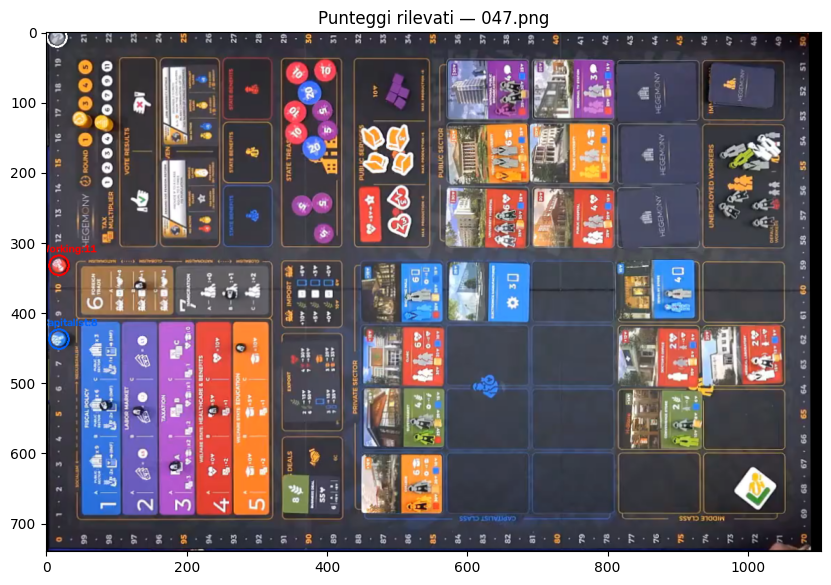

In [68]:
folder_path = "../dataset/Game_2/"
img1 = cv2.imread(os.path.join(folder_path, "043.png"))
img2 = cv2.imread(os.path.join(folder_path, "045.png"))
img3 = cv2.imread(os.path.join(folder_path, "020.png"))
# altri set provati: 041 027 019 / 007 039 035 / 025 015 017

CLASS_DRAW_COLORS = {          # colori BGR per l'annotazione
    "Working":    (0, 0, 255),
    "Capitalist": (255, 100, 0),
    "Middle":     (0, 215, 255),
    "State":      (255, 255, 255),
}


def read_scores(frame, debug=False, return_tokens=False):
    aligned, valid_mask = align_to_reference(frame)
    if aligned is None:
        return (None, None, []) if return_tokens else (None, None)

    tokens = detect_score_tokens(aligned, valid_mask, debug=debug, ring_mask=ring_mask)

    best = {}
    for t in tokens:
        if t["class"] not in best or t["area"] > best[t["class"]]["area"]:
            best[t["class"]] = t

    annotated = aligned.copy()
    for cls, t in best.items():
        color = CLASS_DRAW_COLORS.get(cls, (0, 255, 0))
        cv2.circle(annotated, t["center"], 14, color, 2)
        cv2.putText(annotated, f"{cls}:{t['score']}",
                    (t["center"][0] - 25, t["center"][1] - 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    scores = {cls: t["score"] for cls, t in best.items()}
    return (scores, annotated, tokens) if return_tokens else (scores, annotated)


# --- Test su tre frame (difensivo: non crasha se un frame fallisce) ---
for name, im in [("043.png", img1), ("045.png", img2), ("047.png", img3)]:
    scores, annotated = read_scores(im, debug=True)
    print(f"\n{name} — Punteggi letti:", scores)
    if annotated is not None:
        show_image(annotated, f"Punteggi rilevati — {name}")
    else:
        print(f"{name}: allineamento fallito, nessuna immagine")

## 8. Tracking dei punteggi lungo la partita
Applichiamo `read_scores` a tutti i frame della cartella. Se in un frame una classe non viene rilevata (mano sopra il tracciato, disco occluso), manteniamo l'ultimo valore noto (*carry forward*). Il risultato è la timeline dei punteggi.

In [75]:
def median3(seq):
    """Filtro mediano a finestra 3 centrata (ignora i None)."""
    out = []
    for i in range(len(seq)):
        window = [v for v in seq[max(0, i-1):i+2] if v is not None]
        out.append(np.median(window) if window else None)
    return out


def isotonic(values):
    """Regressione isotonica: i punteggi non diminuiscono mai.
    I buchi (None) vengono riempiti con l'ultimo valore noto; prima
    della prima lettura il punteggio e' 0 (inizio partita)."""
    result = []
    current_max = 0                      # inizio partita: punteggio 0
    for v in values:
        if v is not None:
            current_max = max(current_max, v)
        result.append(current_max)       # anche per i None: carry dell'ultimo valore
    return result


def track_game(folder, step=1, verbose=True):
    files = sorted(f for f in os.listdir(folder)
                   if f.lower().endswith((".png", ".jpg", ".jpeg")))
    files = files[::step]

    classes = list(CLASS_DRAW_COLORS.keys())
    raw = {c: [] for c in classes}
    frames_ok = []
    last = {c: 0 for c in classes}      # inizio partita: tutti a 0

    for fname in files:
        frame = cv2.imread(os.path.join(folder, fname))
        if frame is None:
            continue
        scores, _, tokens = read_scores(frame, return_tokens=True)
        if scores is None:
            if verbose:
                print(f"{fname}: allineamento fallito, frame saltato")
            continue
        for c in classes:
            cands = [t for t in tokens if t["class"] == c]
            if cands:
                chosen = min(cands, key=lambda t: abs(t["score"] - last[c]))
                raw[c].append(chosen["score"])
                last[c] = chosen["score"]
            else:
                raw[c].append(None)
        frames_ok.append(fname)

    timeline = {c: isotonic(median3(raw[c])) for c in classes}
    return frames_ok, timeline, raw


def evaluate(frames_ok, timeline, gold):
    classes = list(CLASS_DRAW_COLORS.keys())
    print(f"{'Classe':<12}{'MAE':>7}{'Esatti':>9}{'entro ±1':>10}{'N':>5}")
    all_errs = []
    for c in classes:
        errs = []
        for i, f in enumerate(frames_ok):
            key = os.path.splitext(f)[0]
            if key in gold and timeline[c][i] is not None:
                errs.append(abs(timeline[c][i] - gold[key][c]))
        if errs:
            mae = np.mean(errs)
            exact = np.mean([e == 0 for e in errs]) * 100
            near = np.mean([e <= 1 for e in errs]) * 100
            print(f"{c:<12}{mae:>7.2f}{exact:>8.0f}%{near:>9.0f}%{len(errs):>5}")
            all_errs += errs
    print(f"{'TOTALE':<12}{np.mean(all_errs):>7.2f}"
          f"{np.mean([e == 0 for e in all_errs])*100:>8.0f}%"
          f"{np.mean([e <= 1 for e in all_errs])*100:>9.0f}%{len(all_errs):>5}")

    # i frame peggiori, da guardare col debug
    print("\nErrori maggiori:")
    worst = []
    for i, f in enumerate(frames_ok):
        key = os.path.splitext(f)[0]
        if key in gold:
            for c in classes:
                if timeline[c][i] is not None:
                    e = abs(timeline[c][i] - gold[key][c])
                    if e > 3:
                        worst.append((e, f, c, timeline[c][i], gold[key][c]))
    for e, f, c, p, g in sorted(worst, reverse=True)[:10]:
        print(f"  {f} {c}: predetto {p}, vero {g} (errore {e})")



In [77]:
# GOLD STANDARD - Game 2 
GOLD = {
    "001": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "003": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "005": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "006": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "007": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "008": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "010": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 2},
    "011": {"Capitalist": 0,  "Middle": 0,  "Working": 1,  "State": 8},
    "013": {"Capitalist": 0,  "Middle": 6,  "Working": 2,  "State": 9},
    "014": {"Capitalist": 0,  "Middle": 6,  "Working": 6,  "State": 10},
    "015": {"Capitalist": 0,  "Middle": 6,  "Working": 6,  "State": 10},
    "016": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "017": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "018": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "019": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "020": {"Capitalist": 8,  "Middle": 8,  "Working": 11, "State": 20},
    "021": {"Capitalist": 8,  "Middle": 8,  "Working": 16, "State": 21},
    "022": {"Capitalist": 8,  "Middle": 8,  "Working": 16, "State": 21},
    "023": {"Capitalist": 8,  "Middle": 8,  "Working": 22, "State": 21},
    "024": {"Capitalist": 8,  "Middle": 8,  "Working": 22, "State": 24},
    "026": {"Capitalist": 8,  "Middle": 11, "Working": 37, "State": 24},
    "027": {"Capitalist": 8,  "Middle": 11, "Working": 37, "State": 24},
    "029": {"Capitalist": 30, "Middle": 12, "Working": 37, "State": 28},
    "030": {"Capitalist": 30, "Middle": 12, "Working": 37, "State": 31},
    "031": {"Capitalist": 33, "Middle": 13, "Working": 37, "State": 31},
    "032": {"Capitalist": 33, "Middle": 16, "Working": 37, "State": 34},
    "033": {"Capitalist": 33, "Middle": 20, "Working": 43, "State": 35},
    "034": {"Capitalist": 33, "Middle": 20, "Working": 43, "State": 36},
    "035": {"Capitalist": 33, "Middle": 20, "Working": 50, "State": 36},
    "038": {"Capitalist": 31, "Middle": 20, "Working": 53, "State": 36},  
    "039": {"Capitalist": 38, "Middle": 22, "Working": 56, "State": 47},
    "040": {"Capitalist": 38, "Middle": 22, "Working": 63, "State": 47},
    "041": {"Capitalist": 38, "Middle": 22, "Working": 63, "State": 54},
    "042": {"Capitalist": 38, "Middle": 25, "Working": 63, "State": 54},
    "044": {"Capitalist": 38, "Middle": 28, "Working": 63, "State": 54},
    "047": {"Capitalist": 60, "Middle": 32, "Working": 71, "State": 63},
    "048": {"Capitalist": 60, "Middle": 39, "Working": 71, "State": 65},
    "049": {"Capitalist": 60, "Middle": 42, "Working": 71, "State": 65},
    "052": {"Capitalist": 68, "Middle": 45, "Working": 71, "State": 67},
    "054": {"Capitalist": 83, "Middle": 94, "Working": 80, "State": 80},
    "055": {"Capitalist": 96, "Middle": 94, "Working": 80, "State": 93},  
}

Classe          MAE   Esatti  entro ±1    N
Working        0.15      93%       98%   41
Capitalist     0.05      98%       98%   41
Middle         0.44      83%       85%   41
State          0.38      80%       98%   41
TOTALE         0.25      88%       95%  164

Errori maggiori:
  019.png State: predetto 20.0, vero 11 (errore 9.0)
  011.png Middle: predetto 6.0, vero 0 (errore 6.0)
  054.png Working: predetto 75.5, vero 80 (errore 4.5)

Analizzati 44 frame


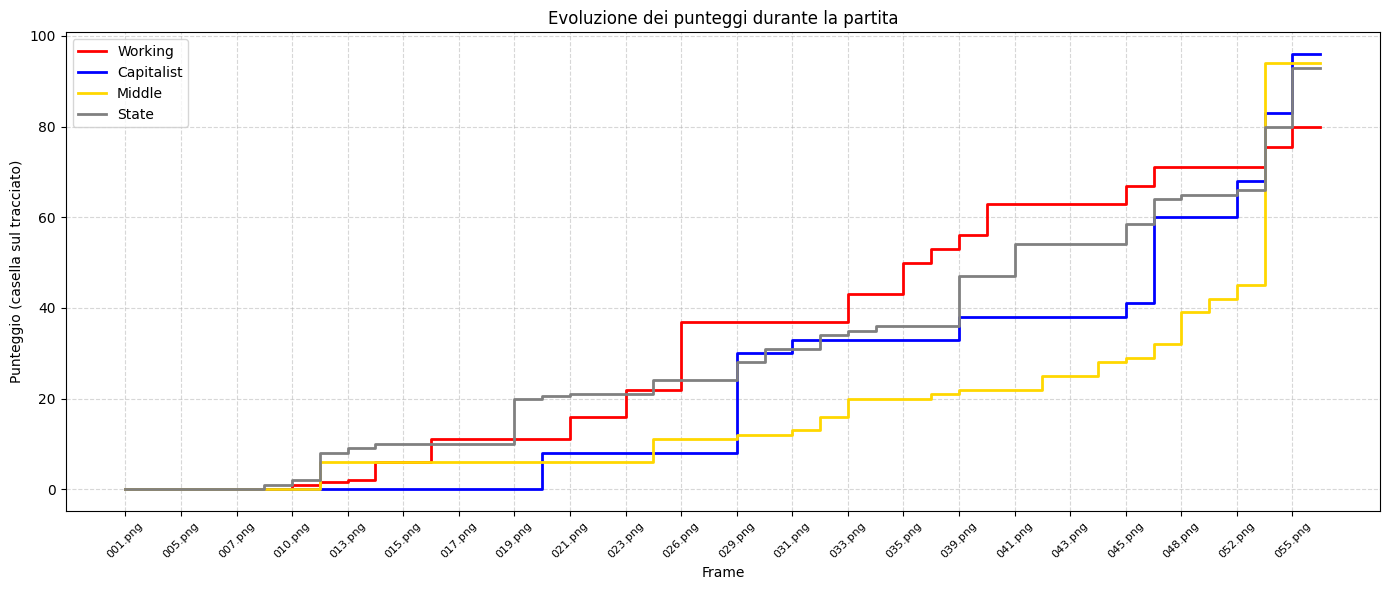

In [78]:
frames_ok, timeline, raw = track_game("../dataset/Game_2/", step=1, verbose=True)
evaluate(frames_ok, timeline, GOLD)
print(f"\nAnalizzati {len(frames_ok)} frame")

# --- Grafico della timeline ---
# --- Grafico della timeline ---
PLOT_COLORS = {"Working": "red", "Capitalist": "blue",
               "Middle": "gold", "State": "grey"}

plt.figure(figsize=(14, 6))
x = range(len(frames_ok))
for cls, values in timeline.items():
    vals = [v if v is not None else np.nan for v in values]
    plt.step(x, vals, where="post", label=cls,
             color=PLOT_COLORS.get(cls), linewidth=2)

plt.xticks(list(x)[::max(1, len(frames_ok)//15)],
           [frames_ok[i] for i in range(0, len(frames_ok), max(1, len(frames_ok)//15))],
           rotation=45, fontsize=8)
plt.ylabel("Punteggio (casella sul tracciato)")
plt.xlabel("Frame")
plt.title("Evoluzione dei punteggi durante la partita")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
# Appendice didattica: analisi del frame ed edge detection
Le sezioni seguenti (dal notebook di analisi originale) confrontano tecniche di preprocessing e operatori di edge detection, e mostrano il metodo edge-based di detection usato inizialmente per le pedine. Sono mantenute a scopo di **confronto e documentazione nel report**: la lettura dei punteggi nella pipeline principale usa invece la differenza col riferimento vuoto (sezioni 5–8), più robusta per questo compito.

## A1. Preprocessing

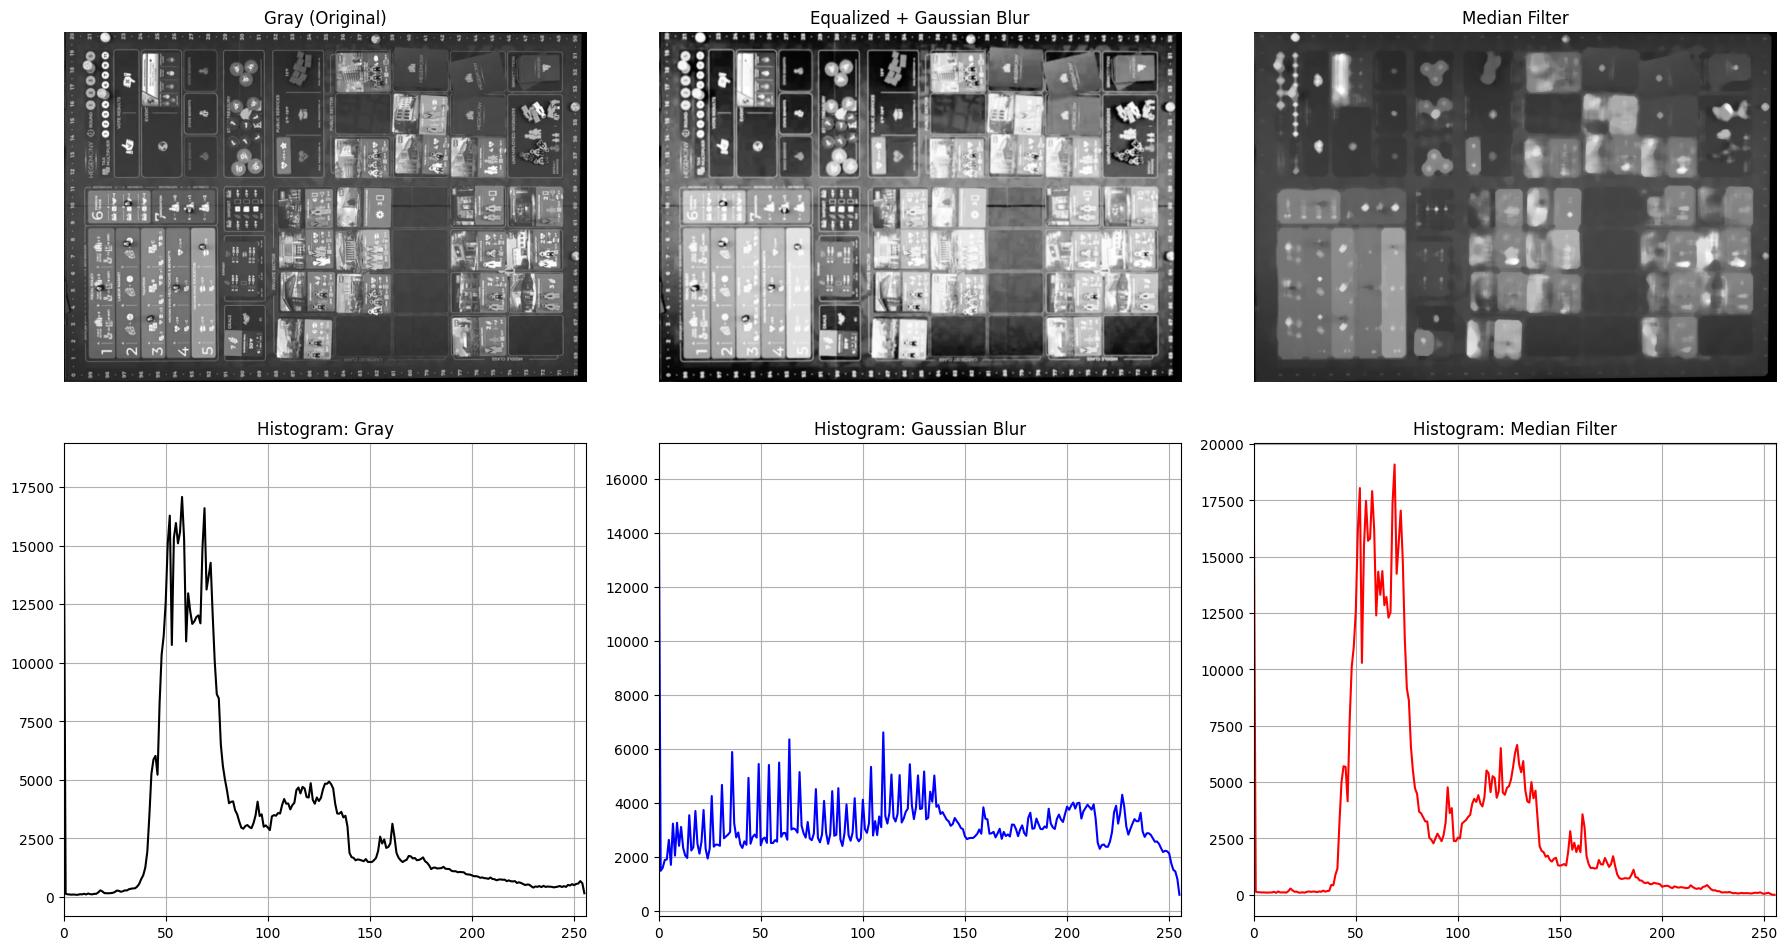

In [13]:
map_img = aligned.copy()

gray = cv2.cvtColor(map_img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)
blur_gaussian = cv2.GaussianBlur(equalized, (5, 5), 0)
blur_median = cv2.medianBlur(gray, 15)

hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_gaussian = cv2.calcHist([blur_gaussian], [0], None, [256], [0, 256])
hist_median = cv2.calcHist([blur_median], [0], None, [256], [0, 256])

plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1); plt.imshow(gray, cmap='gray'); plt.title("Gray (Original)"); plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(blur_gaussian, cmap='gray'); plt.title("Equalized + Gaussian Blur"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(blur_median, cmap='gray'); plt.title("Median Filter"); plt.axis("off")
plt.subplot(2, 3, 4); plt.plot(hist_gray, color='black'); plt.title("Histogram: Gray"); plt.xlim([0, 256]); plt.grid(True)
plt.subplot(2, 3, 5); plt.plot(hist_gaussian, color='blue'); plt.title("Histogram: Gaussian Blur"); plt.xlim([0, 256]); plt.grid(True)
plt.subplot(2, 3, 6); plt.plot(hist_median, color='red'); plt.title("Histogram: Median Filter"); plt.xlim([0, 256]); plt.grid(True)
plt.tight_layout()
plt.show()

## A2. Confronto tra operatori di edge detection (implementazioni manuali)

Processing manual operators (puo' richiedere qualche secondo)...
Processing complete!


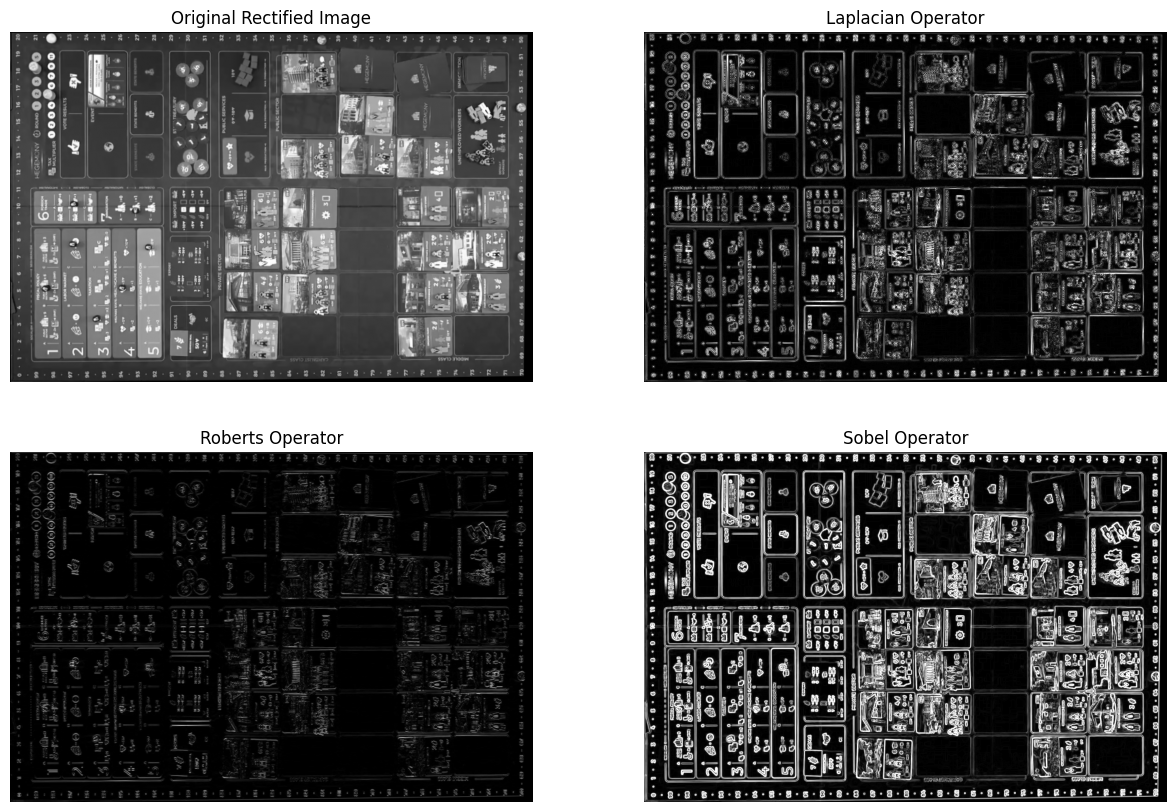

In [14]:
def robert(img):
    img = img.astype(np.int32).copy()
    out = np.zeros_like(img)
    r, c = img.shape
    kernel = np.array([[-1, -1], [1, 1]])
    for x in range(r - 1):
        for y in range(c - 1):
            out[x, y] = abs((kernel * img[x:x+2, y:y+2]).sum())
    return np.uint8(np.clip(out, 0, 255))

def sobel(img):
    img = img.astype(np.float64)
    r, c = img.shape
    new_image = np.zeros((r, c))
    kX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kY = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    for i in range(r - 2):
        for j in range(c - 2):
            gx = abs(np.sum(img[i:i+3, j:j+3] * kX))
            gy = abs(np.sum(img[i:i+3, j:j+3] * kY))
            new_image[i+1, j+1] = (gx**2 + gy**2) ** 0.5
    return np.uint8(np.clip(new_image, 0, 255))

def laplace(img):
    img = img.astype(np.float64)
    r, c = img.shape
    new_image = np.zeros((r, c))
    kL = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    for i in range(r - 2):
        for j in range(c - 2):
            new_image[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * kL))
    return np.uint8(np.clip(new_image, 0, 255))

print("Processing manual operators (puo' richiedere qualche secondo)...")
img_laplace = laplace(gray)
img_robert  = robert(gray)
img_sobel   = sobel(gray)
print("Processing complete!")

plt.figure(figsize=(15, 10))
plt.subplot(221); plt.title("Original Rectified Image"); plt.imshow(gray, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(222); plt.title("Laplacian Operator"); plt.imshow(img_laplace, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(223); plt.title("Roberts Operator"); plt.imshow(img_robert, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(224); plt.title("Sobel Operator"); plt.imshow(img_sobel, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.show()

## A3. Canny e metodo edge-based (per confronto con la pipeline principale)
Il metodo edge-based rileva contorni sia dei numeri stampati sia delle pedine, e deve poi separarli con filtri geometrici: è la sua debolezza strutturale per il tracking dei punteggi, ed è il motivo per cui la pipeline principale usa la differenza col riferimento vuoto.

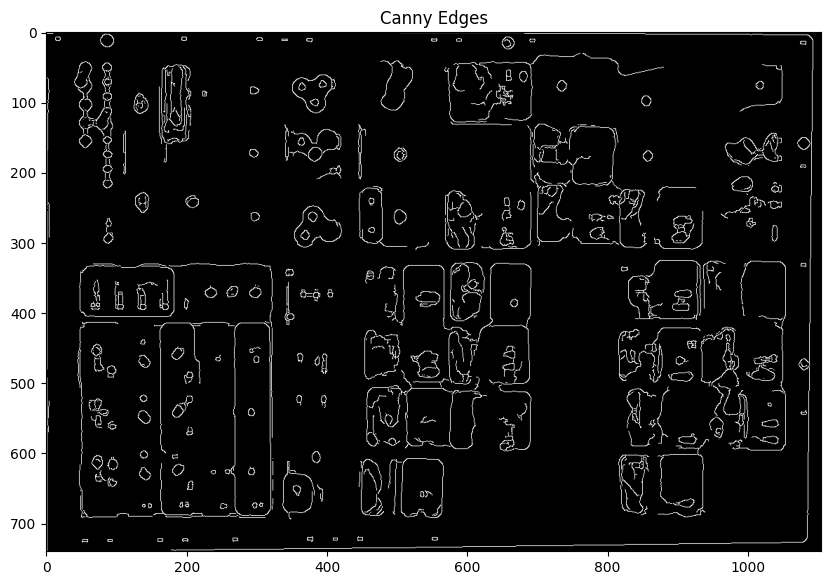

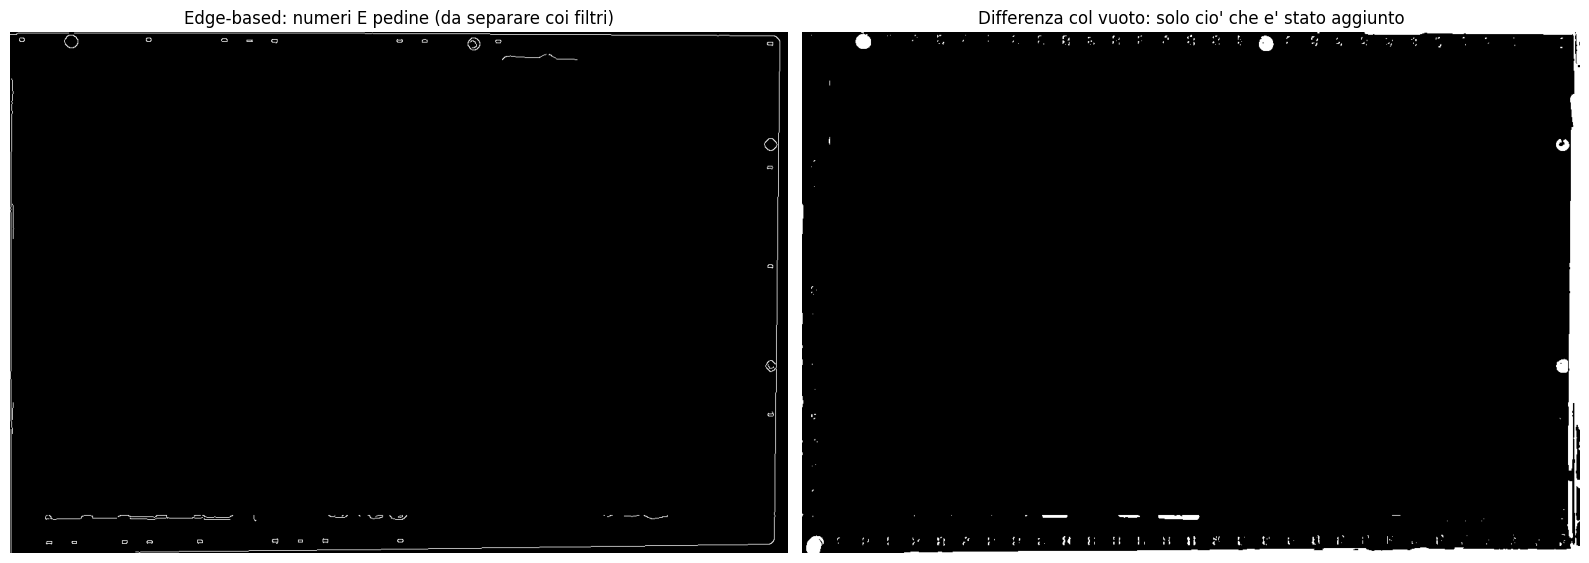

In [15]:
edges = cv2.Canny(blur_median, 30, 100)
show_image(edges, "Canny Edges", cmap='gray')

# Confronto diretto: cosa vede Canny vs cosa vede la differenza nel tracciato
mask_canny = cv2.bitwise_and(edges, ring_mask)

frame_blur = cv2.GaussianBlur(map_img, (5, 5), 0)
diff = cv2.absdiff(frame_blur, _empty_blur).max(axis=2).astype(np.uint8)
_, mask_diff = cv2.threshold(cv2.bitwise_and(diff, ring_mask),
                             DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(16, 6))
plt.subplot(121); plt.imshow(mask_canny, cmap='gray')
plt.title("Edge-based: numeri E pedine (da separare coi filtri)"); plt.axis('off')
plt.subplot(122); plt.imshow(mask_diff, cmap='gray')
plt.title("Differenza col vuoto: solo cio' che e' stato aggiunto"); plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusioni
La pipeline finale risponde all'obiettivo del progetto (tracking dei punteggi) combinando i punti di forza dei due lavori:
- dalla parte geometrica: rettifica robusta via **omografia** (ORB + GMS + RANSAC), che rende ogni frame confrontabile pixel per pixel con il riferimento;
- dalla parte di analisi: il modello del **tracciato** e la lettura per **differenza + classificazione colore**, evoluzione della background subtraction abbozzata e del rilevamento a contorni.

Sviluppi possibili: filtro temporale sulla timeline (un punteggio non può diminuire/saltare arbitrariamente tra frame vicini), gestione esplicita dell'occlusione (maschera "mano" da blob grandi), estensione della stessa tecnica alle altre aree del tabellone (`locate_politics`).